# A set of scaffolds from CheMBL lead-optimization papers

I started looking at collecting a set of scaffolds from med chem papers [a long time ago](https://rdkit.blogspot.com/2015/05/a-set-of-scaffolds-from-chembl-papers.html). I've gone back and refined the analysis a few times, but I haven't written anything about it. This is an update for the most recent refinement I've done.

Instead of general ChEMBL papers, here I use sets of compounds from lead-optimization datasets (terminolog and explanations [in this blog post](https://greglandrum.github.io/rdkit-blog/posts/2026-07-16-identifying-lead-opt-docs.html). The general idea remains the same: approximate the scaffold for the compounds in a document as the maximum common substructure that covers a large fraction (generally 90%) of the compounds in the paper. In the previous analysis I used a fuzzy MCS that ignored atom types. I will repeat that here but also look for a specific MCS (i.e. one with specific atom types). In an attempt to only focus on the chemical series that was actually explored in the paper, for this analysis I use only the "local" compounds, those that are not present in a large number of other documents.

**TL;DR** After some experimentation, I ended up using specific MCSs (all atoms specified) to locate scaffolds in the lead-optimization data sets. I define a scaffold as the MCS that hits at least 80% of the molecules in the data set. In order to ensure that the scaffolds are of reasonable size, I only keep scaffolds where the number of atoms is at least 60% of the average number of atoms for molecules in the data set.


# On to the work

## Start with the preliminaries

We need to do a bunch of imports and define some functions we'll use later.



In [1]:
import numpy
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
from rdkit.Chem import PandasTools
from rdkit import Chem
from rdkit.Chem import rdFMCS as MCS
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)
import pickle
from rdkit import rdBase
print(rdBase.rdkitVersion)
%load_ext sql
%config SqlMagic.feedback = False
%config SqlMagic.named_parameters="enabled"
import time
print(time.asctime())

2026.03.5
Tue Aug 25 15:14:10 2026


In [2]:
# define a function to convert a query molecule to SVG

from IPython.display import SVG
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
def moltosvg(mol,molSize=(450,250),kekulize=True):
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except:
            mc = Chem.Mol(mol)
    if not mc.GetNumConformers():
        rdDepictor.Compute2DCoords(mc)
    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0],molSize[1])
    # the MolDraw2D code is not very good at dealing with atom queries,
    # this is a workaround
    opts = drawer.drawOptions()
    for atom in mc.GetAtoms():
        if atom.HasQuery() and atom.DescribeQuery().find('AtomAtomicNum')!=0:
            opts.atomLabels[atom.GetIdx()]=atom.GetSmarts()
    drawer.DrawMolecule(mc)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return svg

In [3]:
# define a function to find the MCS for a set of molecules and return some summary info about that MCS

import time
# we will use a namedtuple to return the results
from collections import namedtuple
MCSRes=namedtuple('MCSRes',('smarts','numAtoms','numMols','avgNumMolAtoms','mcsTime'))

def MCS_Report(ms,printSmarts=True,
               atomCompare=MCS.AtomCompare.CompareAny,
               bondCompare=MCS.BondCompare.CompareAny,
               completeRingsOnly=True,
               **kwargs):
    t1=time.time()
    mcs = MCS.FindMCS(ms,atomCompare=atomCompare,bondCompare=bondCompare,timeout=30,completeRingsOnly=completeRingsOnly,
                      **kwargs)
    t2=time.time()
    nAts = numpy.array([x.GetNumAtoms() for x in ms])
    print('Mean nAts %.1f, mcs nAts: %d'%(nAts.mean(),mcs.numAtoms))
    if printSmarts: 
        print(mcs.smartsString)
    mcsM = Chem.MolFromSmarts(mcs.smartsString)         
    mcsM.UpdatePropertyCache(False)
    Chem.SetHybridization(mcsM)
    svg = moltosvg(mcsM,kekulize=False)
    tpl = MCSRes(mcs.smartsString,mcs.numAtoms,len(ms),nAts,t2-t1)
    return tpl,svg


## Grab the data

Load the lead optimization sets from the earlier blog post:

In [4]:
with open('./results/lead_optimization_sets.pkl','rb') as f:
    df = pickle.load(f)

df.shape

(37295, 7)

In [5]:
df.head()

,doc_id,doc_chembl_id,molregno,compound_chembl_id,compound_type,assay_count,canonical_smiles
0,37919,CHEMBL1140586,416886,CHEMBL250403,local,34,CCCN1CCO[C@H](c2cccc(O)c2)C1
1,37919,CHEMBL1140586,3854,CHEMBL53,reference,3,CN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3
2,37919,CHEMBL1140586,19316,CHEMBL589,reference,3,CCCN(CCC)CCc1cccc2c1CC(=O)N2
3,37919,CHEMBL1140586,88815,CHEMBL301265,reference,3,CCCN[C@H]1CCc2nc(N)sc2C1
4,37919,CHEMBL1140586,259724,CHEMBL155731,local,3,CCCN1CCC[C@@H]2Cc3nc(N)ncc3C[C@H]21


Look at the compounds from one of the papers:

In [6]:
doc_df = df[(df['doc_chembl_id']=='CHEMBL1140586') & (df['compound_type']=='local')]
doc_df.shape

(44, 7)

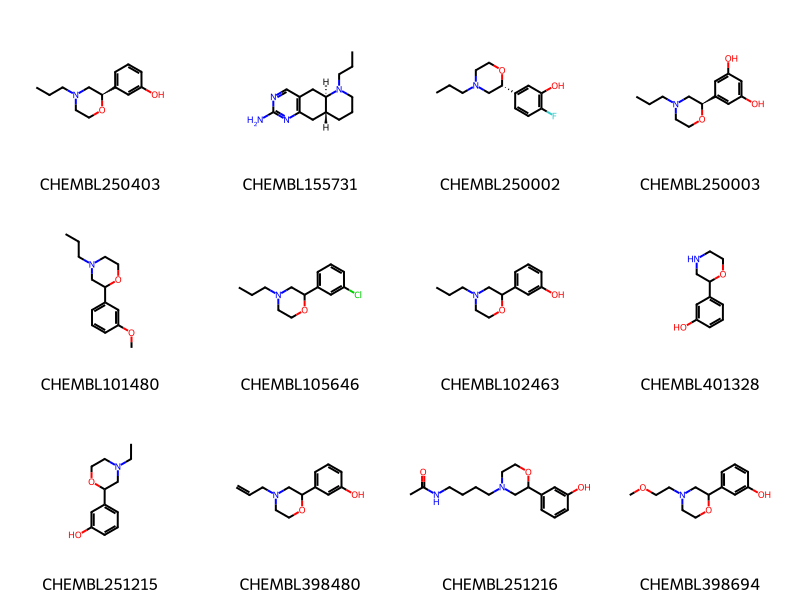

In [7]:
ms = doc_df['canonical_smiles'].apply(Chem.MolFromSmiles).to_list()
Draw.MolsToGridImage(ms[:12],molsPerRow=4,legends=doc_df['compound_chembl_id'].to_list())

And run the MCS analysis:

Mean nAts 17.6, mcs nAts: 15
[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#8]-&@[#6](-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8,#6,#7,#16,#17]


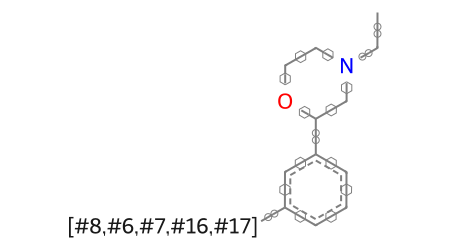

In [8]:
tpl,svg=MCS_Report(ms,threshold=0.9,completeRingsOnly=True)
SVG(svg)

Repeat that, but don't do fuzzy MCS:

Mean nAts 17.6, mcs nAts: 15
[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#8]-&@[#6](-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


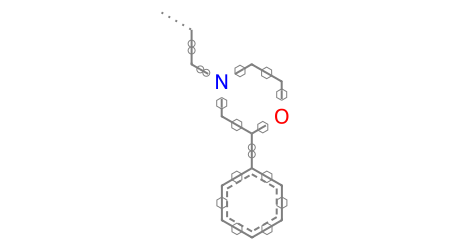

In [9]:
tpl,svg=MCS_Report(ms,threshold=0.9,completeRingsOnly=True,
        atomCompare=MCS.AtomCompare.CompareElements)
SVG(svg)

Run all of the papers and save the results, this takes a while:

In [6]:
import pickle


def run_doc(df, doc_id, threshold=0.9):
    doc_df = df[(df['doc_chembl_id'] == doc_id)
                & (df['compound_type'] == 'local')]

    ms = doc_df['canonical_smiles'].apply(Chem.MolFromSmiles).to_list()
    print(f'{len(ms)} molecules found for document {doc_id}')
    if len(ms) < 2:
        return None
    tpl, svg = MCS_Report(ms, threshold=threshold, completeRingsOnly=True)
    smis = doc_df['canonical_smiles'].to_list()
    return (doc_id, smis, tpl, svg)

In [ ]:
results = []
seen = [x[0][0] for x in results if x is not None]

doc_ids = df['doc_chembl_id'].unique()
nrows = len(doc_ids)
for i,did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    if did in seen:
        continue
    tpl = run_doc(df,did)
    results.append(tpl)
    if not (i+1)%100:
        pickle.dump(results,open('../data/scaffolds_lead_opt.pkl','wb+'))
pickle.dump(results,open('../data/scaffolds_lead_opt.pkl','wb+'))

Write a CSV file too:

In [ ]:
tmp = []
for row in results:
    tmp.append((row[0],row[2].smarts,str(row[2].numAtoms/row[2].avgNumMolAtoms.mean())))
with open('../data/scaffolds_lead_opt.txt','w+') as outf:
    print('doc_chembl_id\tsmarts\tfraction_of_average_molecule_size',file=outf)
    for row in tmp:
        print('\t'.join(row),file=outf)

In [10]:
import pickle
results = pickle.load(open('../data/scaffolds_lead_opt.pkl','rb'))


In [11]:
len(results)

770

Repeat, but use the atom types (elements) in the MCS:

In [7]:
import pickle


def run_doc2(df, doc_id, threshold=0.9):
    doc_df = df[(df['doc_chembl_id'] == doc_id)
                & (df['compound_type'] == 'local')]

    ms = doc_df['canonical_smiles'].apply(Chem.MolFromSmiles).to_list()
    print(f'{len(ms)} molecules found for document {doc_id}')
    if len(ms) < 2:
        return None
    tpl, svg = MCS_Report(ms,
                          threshold=threshold,
                          completeRingsOnly=True,
                          atomCompare=MCS.AtomCompare.CompareElements)
    smis = doc_df['canonical_smiles'].to_list()
    return (doc_id, smis, tpl, svg)


In [ ]:
results2 = []
seen = [x[0] for x in results2 if x is not None]

doc_ids = df['doc_chembl_id'].unique()
nrows = len(doc_ids)
for i,did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    if did in seen:
        continue
    tpl = run_doc2(df,did)
    results2.append(tpl)
    if not (i+1)%100:
      pickle.dump(results2,open('../data/scaffolds_lead_opt_specific.pkl','wb+'))
pickle.dump(results2,open('../data/scaffolds_lead_opt_specific.pkl','wb+'))

In [ ]:
tmp = []
for row in results2:
    tmp.append((row[0], row[2].smarts,
                str(row[2].numAtoms / row[2].avgNumMolAtoms.mean())))
with open('../data/scaffolds_lead_opt_specific.txt', 'w+') as outf:
    print('doc_chembl_id\tsmarts\tfraction_of_average_molecule_size',
          file=outf)
    for row in tmp:
        print('\t'.join(row), file=outf)

# Look at some results

The data is organized in a dictionary with one entry per paper.

The `MCS_Report()` function defined above prints out the mean number of atoms per molecule in the input along with the size of the MCS. This is intended to help assess whether or not the MCS is actually a scaffold.

How many "scaffolds" of each type do we have in total?

In [4]:
import pickle
results = pickle.load(open('../data/scaffolds_lead_opt.pkl', 'rb'))
results2 = pickle.load(open('../data/scaffolds_lead_opt_specific.pkl', 'rb'))

In [9]:
len(results),len(results2)

(770, 770)

Convert to dataframes:

In [5]:
tbl = []
for row in results:
    doc_id,smis,tpl,svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl.append((doc_id,tpl.numAtoms,tpl.avgNumMolAtoms.mean(),tpl.smarts,tpl.mcsTime))
scaff_df = pd.DataFrame(data=tbl,columns=('doc_chembl_id','numAtoms','avgNumMolAtoms','smarts','time'))

tbl2 = []
for row in results2:
    doc_id,smis,tpl,svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl2.append((doc_id,tpl.numAtoms,tpl.avgNumMolAtoms.mean(),tpl.smarts,tpl.mcsTime))
scaff_df2 = pd.DataFrame(data=tbl2,columns=('doc_chembl_id','numAtoms','avgNumMolAtoms','smarts','time'))
scaff_df2.head(5)

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
0,CHEMBL1140586,15,17.590909,"[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-...",0.004567
1,CHEMBL1143305,16,32.612903,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,0.290015
2,CHEMBL1152282,16,31.641026,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,0.008485
3,CHEMBL1153392,17,20.146341,[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:...,0.033392
4,CHEMBL1136951,6,29.787879,"[#6]-&!@[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[...",0.015072


How many scaffolds are reasonably sized, containing more than six atoms?

In [16]:
len(scaff_df[scaff_df.numAtoms > 6]), len(scaff_df2[scaff_df2.numAtoms > 6])

(764, 735)

How many make up a large percentage of the average molecule size: containing at least 60% as many atoms?

In [17]:
len(scaff_df[scaff_df.numAtoms / scaff_df.avgNumMolAtoms > 0.6]), len(
    scaff_df2[scaff_df2.numAtoms / scaff_df2.avgNumMolAtoms > 0.6])

(471, 285)

Not bad! It's still worth looking at the ones that are super small:

In [12]:
scaff_df[scaff_df.numAtoms <= 6].head()

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
159,CHEMBL4196006,6,15.809524,[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1,0.007589
187,CHEMBL4342498,2,33.600000,"[#8,#6]=,-;!@[#6,#7,#8]",30.139387
222,CHEMBL4402562,4,20.441176,"[#8,#6,#7]=,-;!@[#6,#16](-,=;!@[#8,#6,#7])-,=;...",0.001956
663,CHEMBL6087400,6,17.228070,"[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@...",0.036301
700,CHEMBL6103656,6,17.742857,"[#6]1:,-;@[#6]-,:;@[#6,#7]-,:;@[#6,#7]-,:;@[#7...",0.284387


In [13]:
scaff_df2[scaff_df2.numAtoms <= 6].head()

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
4,CHEMBL1136951,6,29.787879,"[#6]-&!@[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[...",0.015072
27,CHEMBL2034824,2,36.095238,[#6]-&!@[#6],30.271687
54,CHEMBL3352559,6,23.371429,[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1,0.005176
86,CHEMBL3785091,3,28.728395,"[#8]=,-;!@[#6]-&!@[#6]",0.013217
106,CHEMBL4011608,6,18.257143,[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1,0.006619


Look at compounds from one of those documents:

There are 35 molecules for this document


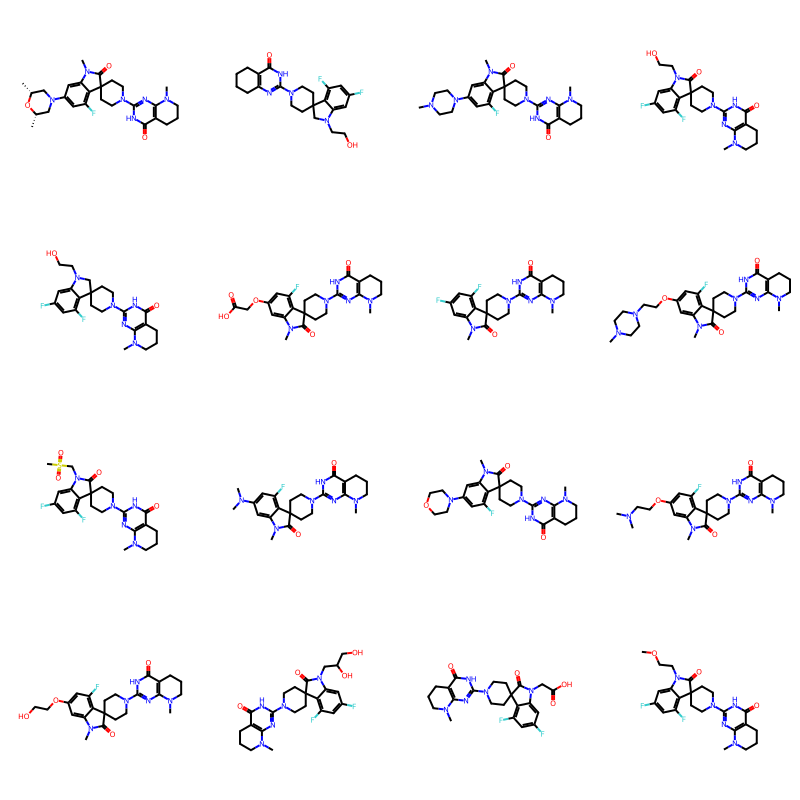

In [14]:
a = [x for x in results2 if x[0]=='CHEMBL4342498'][0]
print(f'There are {len(a[1])} molecules for this document')
mols = [Chem.MolFromSmiles(y) for y in a[1]]
Draw.MolsToGridImage(mols[:16],molsPerRow=4)

There is clearly a scaffold there, it just doesn't cover 90% of the molecules.

The molecules that don't match the scaffold:

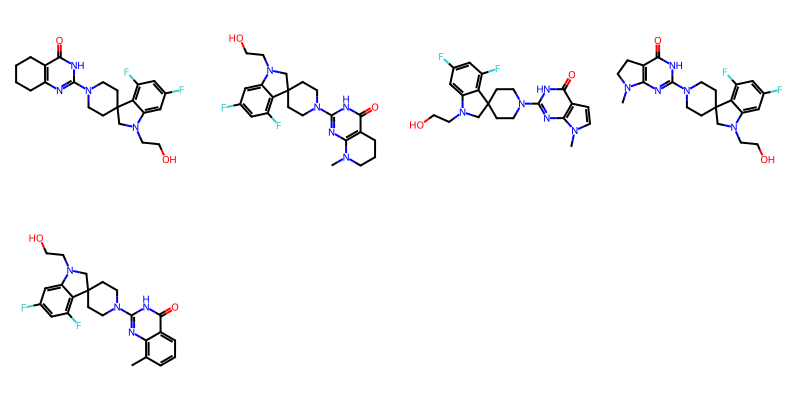

In [15]:
Draw.MolsToGridImage([x for x in mols if not x.HasSubstructMatch(Chem.MolFromSmarts('C1C(=O)Nc2ccccc12'))],molsPerRow=4)

What if we only require that the scaffold cover 80 or 85% of the molecules?

Start with the fuzzy MCS:

In [10]:
tpl = run_doc(df, 'CHEMBL4342498', threshold=0.8)

35 molecules found for document CHEMBL4342498


Mean nAts 33.6, mcs nAts: 28
[#8]=&!@[#6]1:&@[#7]:&@[#6](-&!@[#7]2-&@[#6]-&@[#6]-&@[#6]3(-&@[#6]-&@[#6]-&@2)-&@[#6]-&@[#7](-&@[#6]2:&@[#6]-&@3:&@[#6](:&@[#6]:&@[#6](:&@[#6]:&@2)-&!@[#9,#7,#8])-&!@[#9])-&!@[#6]):&@[#7]:&@[#6]2:&@[#6]:&@1-,:;@[#6]-,:;@[#6]-,:;@[#6]-,:;@[#6,#7]-,:;@2


Now the specific MCS:

In [11]:
tpl2 = run_doc2(df, 'CHEMBL4342498', threshold=0.85)

35 molecules found for document CHEMBL4342498
Mean nAts 33.6, mcs nAts: 23
[#8]=&!@[#6]1:&@[#7]:&@[#6](-&!@[#7]2-&@[#6]-&@[#6]-&@[#6]3(-&@[#6]-&@[#6]-&@2)-&@[#6]-&@[#7](-&@[#6]2:&@[#6]-&@3:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@2)-&!@[#9])-&!@[#6]):&@[#7]:&@[#6]:&@[#6]:&@1


In [26]:
tpl2 = run_doc2(df, 'CHEMBL4342498', threshold=0.85)

35 molecules found for document CHEMBL4342498
Mean nAts 33.6, mcs nAts: 2
[#8]=,-;!@[#6]


Repeat the run and only require that the scaffold match 80% of the molecules in the documents where the MCS covered less than 60% of the average number of atoms

In [ ]:
relaxed_results2 = []

scaff_df2['scaff_frac'] = scaff_df2.numAtoms / scaff_df2.avgNumMolAtoms

to_expand = scaff_df2[scaff_df2.scaff_frac < 0.6]

doc_ids = to_expand.doc_chembl_id.unique().tolist()
nrows = len(doc_ids)
for i, did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    tpl = run_doc2(df, did, threshold=0.8)
    relaxed_results2.append(tpl)

pickle.dump(relaxed_results2, open('../data/scaffolds_lead_opt_specific_relaxed.pkl', 'wb+'))

In [8]:
relaxed_results2 = pickle.load(open('../data/scaffolds_lead_opt_specific_relaxed.pkl', 'rb'))

In [9]:
tbl2 = []
for row in relaxed_results2:
    doc_id, smis, tpl, svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl2.append((doc_id, tpl.numAtoms, tpl.avgNumMolAtoms.mean(), tpl.smarts,
                 tpl.mcsTime))
relaxed_scaff_df2 = pd.DataFrame(data=tbl2,
                         columns=('doc_chembl_id', 'numAtoms',
                                  'avgNumMolAtoms', 'smarts', 'time'))
relaxed_scaff_df2.head(5)

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
0,CHEMBL1143305,19,32.612903,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,1.477257
1,CHEMBL1152282,22,31.641026,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,7.046058
2,CHEMBL1136951,12,29.787879,[#6]1:&@[#6]:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@1...,0.206350
3,CHEMBL1136988,25,32.085714,[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)...,15.545042
4,CHEMBL1153522,16,28.151515,[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)...,1.069422


Repeat the run again and only require that the scaffold match 70% of the molecules in the documents where the MCS from the 80% threshold covered less than 60% of the average number of atoms

In [ ]:
relaxed_results3 = []

relaxed_scaff_df2[
    'scaff_frac'] = relaxed_scaff_df2.numAtoms / relaxed_scaff_df2.avgNumMolAtoms

to_expand = relaxed_scaff_df2[relaxed_scaff_df2.scaff_frac < 0.6]

doc_ids = to_expand.doc_chembl_id.unique().tolist()
nrows = len(doc_ids)
for i, did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    tpl = run_doc2(df, did, threshold=0.7)
    relaxed_results3.append(tpl)

pickle.dump(relaxed_results3,
            open('../data/scaffolds_lead_opt_specific_very_relaxed.pkl', 'wb+'))

In [10]:
relaxed_results3 = pickle.load(open('../data/scaffolds_lead_opt_specific_very_relaxed.pkl', 'rb'))

In [11]:
tbl2 = []
for row in relaxed_results3:
    doc_id, smis, tpl, svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl2.append((doc_id, tpl.numAtoms, tpl.avgNumMolAtoms.mean(), tpl.smarts,
                 tpl.mcsTime))
relaxed_scaff_df3 = pd.DataFrame(data=tbl2,
                                 columns=('doc_chembl_id', 'numAtoms',
                                          'avgNumMolAtoms', 'smarts', 'time'))

relaxed_scaff_df3['scaff_frac'] = relaxed_scaff_df3.numAtoms / relaxed_scaff_df3.avgNumMolAtoms

len(relaxed_scaff_df3[relaxed_scaff_df3.scaff_frac > 0.6])

98

In [13]:
scaff_df2['scaff_frac'] = scaff_df2.numAtoms / scaff_df2.avgNumMolAtoms
relaxed_scaff_df2['scaff_frac'] = relaxed_scaff_df2.numAtoms / relaxed_scaff_df2.avgNumMolAtoms



Combine the sets of scaffolds that we've found so far:

In [14]:
combined_df = pd.concat([scaff_df2[scaff_df2.scaff_frac>0.6], relaxed_scaff_df2[relaxed_scaff_df2.scaff_frac>0.6], relaxed_scaff_df3[relaxed_scaff_df3.scaff_frac>0.6]])
print(combined_df.shape)
combined_df.head()

(500, 6)


,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time,scaff_frac
0,CHEMBL1140586,15,17.590909,"[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-...",0.004567,0.852713
3,CHEMBL1153392,17,20.146341,[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:...,0.033392,0.843826
6,CHEMBL1138529,26,41.187500,[#6]-&!@[#7]1:&@[#6]:&@[#7]:&@[#6]:&@[#6]:&@1-...,30.205141,0.631259
9,CHEMBL1156284,35,40.967742,[#6]-&!@[#6](-&!@[#8]-&!@[#6]1-&@[#6]-&@[#7]2-...,30.035294,0.854331
10,CHEMBL1212923,16,25.967742,[#6](=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]-&@[#7](-...,0.175085,0.616149


Make sure we don't have duplicates in there:

In [15]:
len(set(combined_df.doc_chembl_id.tolist()))

500

And save those

In [16]:
combined_df.to_csv('../data/scaffolds_lead_opt_specific_combined.csv',index=False)

Now let's look at some of them:

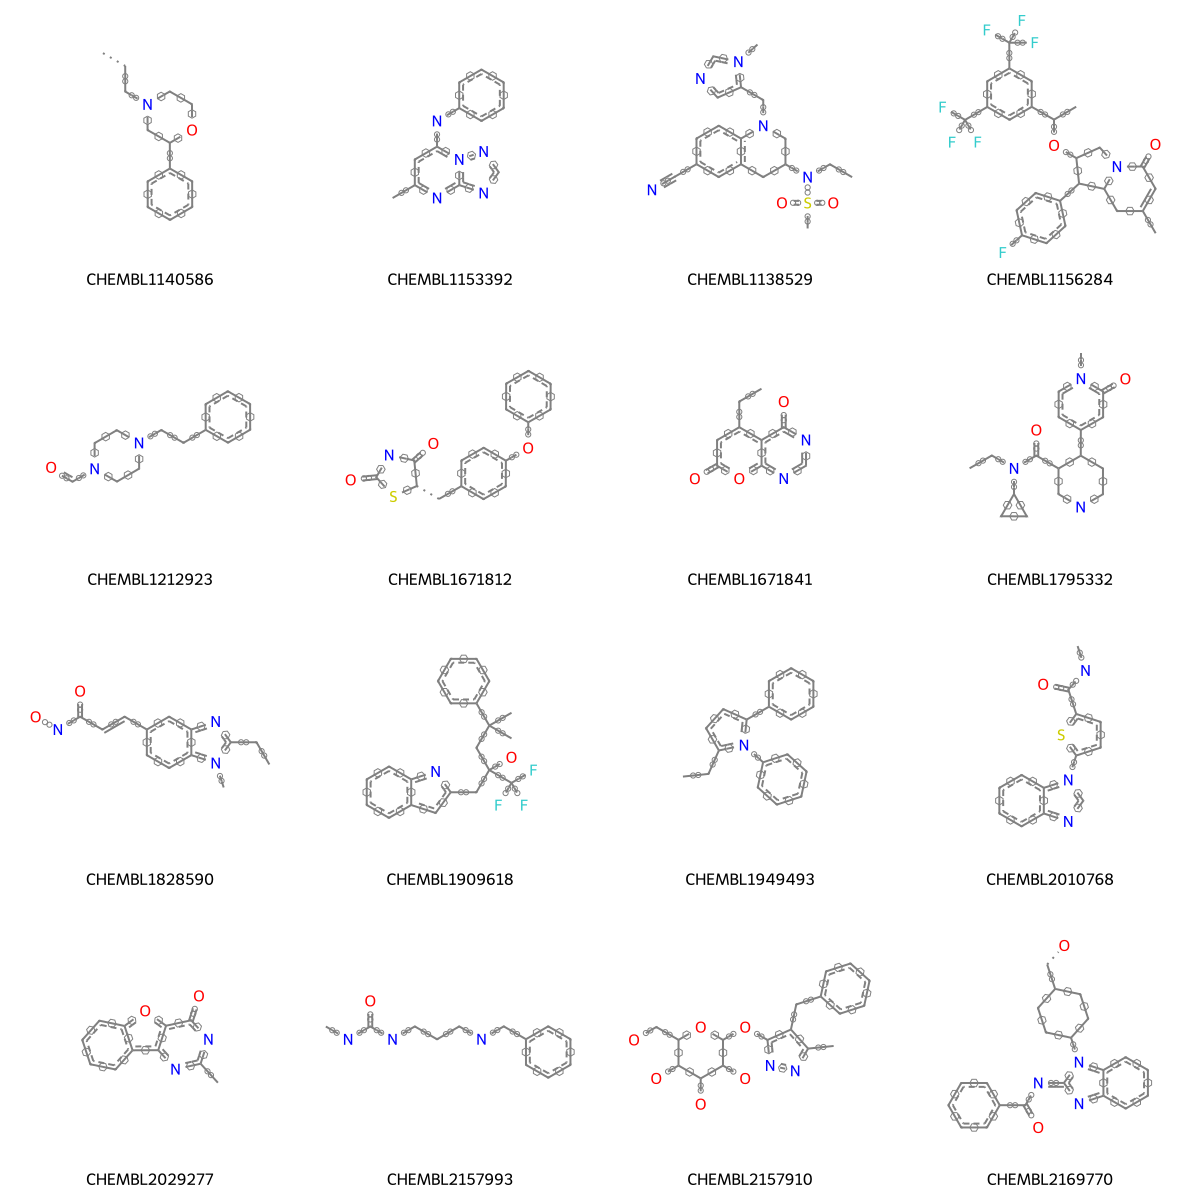

In [18]:
scaffs = [Chem.MolFromSmarts(x) for x in combined_df.smarts.tolist()]
Draw.MolsToGridImage(scaffs[:16],molsPerRow=4,legends=combined_df.doc_chembl_id.tolist()[:16], subImgSize=(300,300))

We could do a bit of cleaning up here, but these don't look terrible.

# Wrapping up

There's a lot more we can do with this set of scaffolds. There are more posts to come...